# Customer Churn Prediction — Data Exploration

## Objective

This notebook performs an exploratory data analysis (EDA) of the
customer churn training dataset generated from the Gold layer of
the data warehouse.

The objectives are to:

- Understand the structure of the dataset
- Check data quality
- Analyze the churn distribution
- Explore numerical customer behavior features
- Explore categorical customer attributes
- Identify potential relationships between customer behavior and churn
- Detect potential outliers and data issues
- Prepare the dataset for feature engineering and model training

In [1]:
#  Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import urllib.parse
from datetime import datetime
from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

In [2]:
# --------------------------------------------------------------------------
# 1. CONNECTION - update this for your environment
# --------------------------------------------------------------------------
odbc_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-NRD95P9\SQLEXPRESS;"       
    "DATABASE=DataWarehouse;"           
    "Trusted_Connection=yes;"
)
params = urllib.parse.quote_plus(odbc_str)
CONNECTION_STRING = f"mssql+pyodbc:///?odbc_connect={params}"
engine = create_engine(CONNECTION_STRING)

CATEGORICAL_COLS = ["gender", "marital_status", "country"]
FEATURE_COLS = ["recency_days", "frequency", "monetary", "avg_order_value", "tenure_days", "age"]


In [3]:
# --------------------------------------------------------------------------
# 2. LOAD TRAINING DATA
# --------------------------------------------------------------------------
print(">> Loading training data...")
df = pd.read_sql("SELECT * FROM gold.customer_churn_training", engine)
print(f"   {len(df)} customers | churn rate: {df['churned'].mean():.1%}")

>> Loading training data...
   5671 customers | churn rate: 15.8%


## 1. Initial Dataset Overview

We first inspect the dimensions and first observations of the dataset
to understand its structure.

In [4]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 5,671
Number of columns: 11


In [5]:
df.head(10)

,customer_id,recency_days,frequency,monetary,avg_order_value,tenure_days,age,gender,marital_status,country,churned
0,11000,10,2,5742.0,2871.0,-4634,42.0,Male,Married,Australia,False
1,11001,12,2,5795.0,2897.5,-4634,37.0,Male,Single,Australia,False
2,11002,28,2,5695.0,2847.5,-4634,42.0,Male,Married,Australia,False
3,11003,23,2,5719.0,2859.5,-4634,40.0,Female,Single,Australia,False
4,11004,6,2,5777.0,2888.5,-4634,34.0,Female,Single,Australia,False
5,11005,5,2,5737.0,2868.5,-4634,37.0,Male,Single,Australia,False
6,11006,30,2,5735.0,2867.5,-4634,37.0,Female,Single,Australia,False
7,11007,7,2,5792.0,2896.0,-4634,44.0,Male,Married,Australia,False
8,11008,25,2,5687.0,2843.5,-4634,38.0,Female,Single,Australia,False
9,11009,8,2,5672.0,2836.0,-4634,44.0,Male,Single,Australia,False


In [6]:
df.tail()

,customer_id,recency_days,frequency,monetary,avg_order_value,tenure_days,age,gender,marital_status,country,churned
5666,29476,557,1,3400.0,3400.0,-4745,49.0,n/a,Married,Germany,True
5667,29479,146,1,2049.0,2049.0,-4745,44.0,n/a,Married,France,True
5668,29481,534,1,3375.0,3375.0,-4745,48.0,n/a,Single,Germany,True
5669,29482,132,1,2049.0,2049.0,-4745,49.0,n/a,Married,France,True
5670,29483,141,1,2049.0,2049.0,-4747,NaN,n/a,Married,France,True


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5671 entries, 0 to 5670
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      5671 non-null   int64  
 1   recency_days     5671 non-null   int64  
 2   frequency        5671 non-null   int64  
 3   monetary         5671 non-null   float64
 4   avg_order_value  5671 non-null   float64
 5   tenure_days      5671 non-null   int64  
 6   age              5661 non-null   float64
 7   gender           5671 non-null   object 
 8   marital_status   5671 non-null   object 
 9   country          5671 non-null   object 
 10  churned          5671 non-null   bool   
dtypes: bool(1), float64(3), int64(4), object(3)
memory usage: 448.7+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,5671.0,19043.630224,5646.723878,11000.0,14079.5,17966.0,24360.5,29483.0
recency_days,5671.0,312.499206,218.223985,0.0,116.0,289.0,484.5,761.0
frequency,5671.0,1.055898,0.232037,1.0,1.0,1.0,1.0,3.0
monetary,5671.0,2423.316699,1183.393597,2.0,2049.0,2182.0,3578.0,8457.0
avg_order_value,5671.0,2296.790896,1021.819050,2.0,2049.0,2182.0,3578.0,3578.0
tenure_days,5671.0,-4697.834068,43.326912,-4747.0,-4725.0,-4724.0,-4640.0,-4634.0
age,5661.0,42.867691,10.333040,27.0,35.0,41.0,50.0,86.0


In [9]:
df.describe(include="object").T

,count,unique,top,freq
gender,5671,3,Male,2810
marital_status,5671,2,Married,2870
country,5671,8,Australia,1916


In [11]:
df.columns.tolist()

['customer_id',
 'recency_days',
 'frequency',
 'monetary',
 'avg_order_value',
 'tenure_days',
 'age',
 'gender',
 'marital_status',
 'country',
 'churned']

## 2. Data Quality Analysis

Before analyzing customer behavior, we check for missing values,
duplicates, invalid values, and inconsistent data.

In [12]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="missing_percentage",
    ascending=False
)

missing

,missing_count,missing_percentage
age,10,0.176336
recency_days,0,0.000000
customer_id,0,0.000000
frequency,0,0.000000
monetary,0,0.000000
avg_order_value,0,0.000000
tenure_days,0,0.000000
gender,0,0.000000
marital_status,0,0.000000
country,0,0.000000


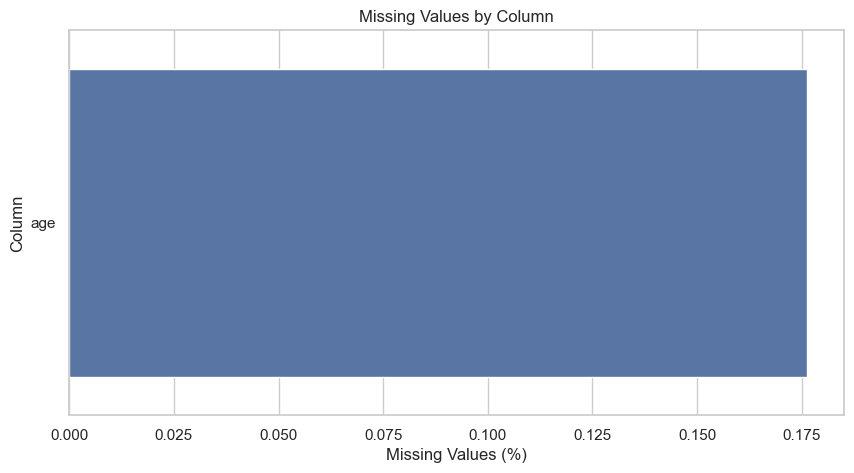

In [13]:
plt.figure(figsize=(10, 5))

missing_nonzero = missing[missing["missing_count"] > 0]

if len(missing_nonzero) > 0:
    sns.barplot(
        x=missing_nonzero["missing_percentage"],
        y=missing_nonzero.index
    )
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Column")
    plt.title("Missing Values by Column")
    plt.show()
else:
    print("No missing values found.")

In [14]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [15]:
duplicate_customers = df["customer_id"].duplicated().sum()

print(f"Duplicate customer IDs: {duplicate_customers:,}")

Duplicate customer IDs: 0


## 3. Churn Distribution

The target variable `churned` indicates whether a customer churned
during the future observation window used to create the training label.

- `0` = customer did not churn
- `1` = customer churned

In [16]:
churn_counts = df["churned"].value_counts().sort_index()

churn_counts

churned
False    4774
True      897
Name: count, dtype: int64

In [17]:
churn_percentage = (
    df["churned"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

churn_percentage

churned
False    84.182684
True     15.817316
Name: proportion, dtype: float64

churned
False    84.182684
True     15.817316
Name: proportion, dtype: float64

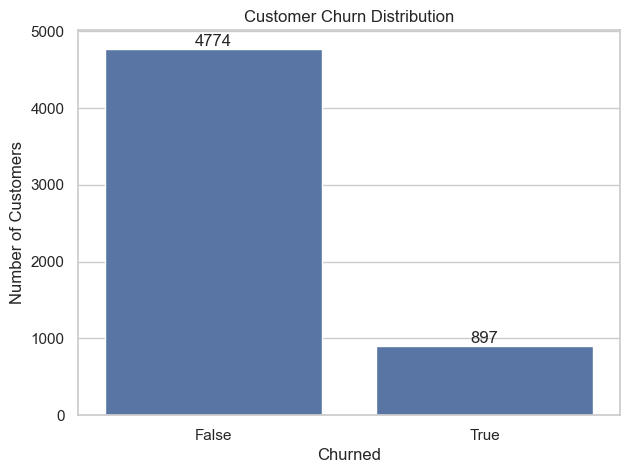

In [19]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="churned"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## 4. Numerical Feature Analysis

The main behavioral features are:

- Recency: number of days since the customer's last order
- Frequency: number of orders
- Monetary: total customer spending
- Average Order Value: average amount spent per order
- Tenure: number of days the customer has been in the system
- Age: customer's age

In [20]:
df[FEATURE_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
recency_days,5671.0,312.499206,218.223985,0.0,116.0,289.0,484.5,761.0
frequency,5671.0,1.055898,0.232037,1.0,1.0,1.0,1.0,3.0
monetary,5671.0,2423.316699,1183.393597,2.0,2049.0,2182.0,3578.0,8457.0
avg_order_value,5671.0,2296.790896,1021.819050,2.0,2049.0,2182.0,3578.0,3578.0
tenure_days,5671.0,-4697.834068,43.326912,-4747.0,-4725.0,-4724.0,-4640.0,-4634.0
age,5661.0,42.867691,10.333040,27.0,35.0,41.0,50.0,86.0


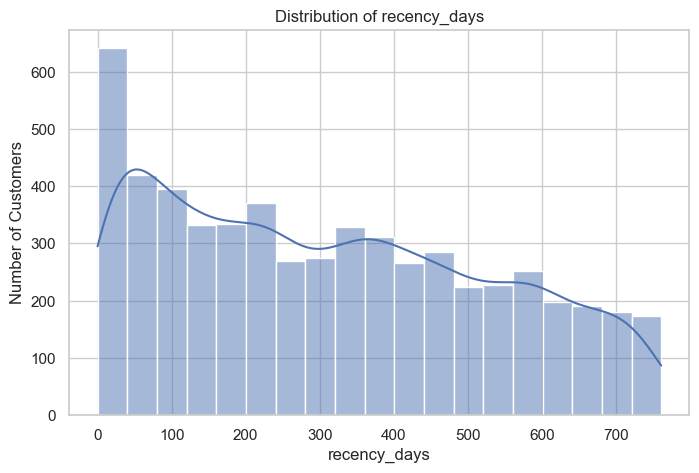

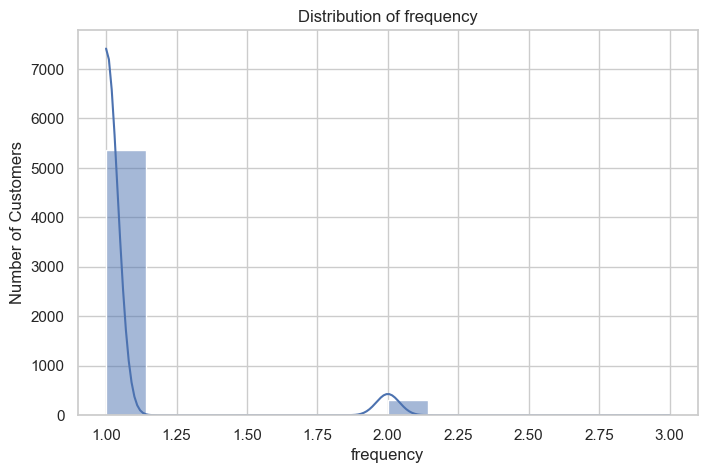

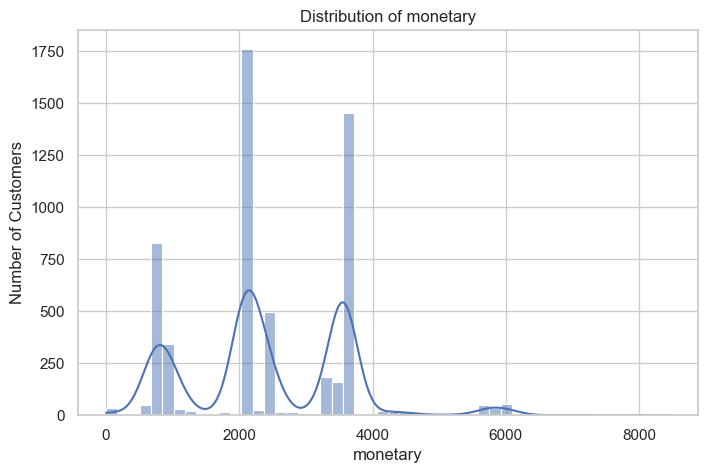

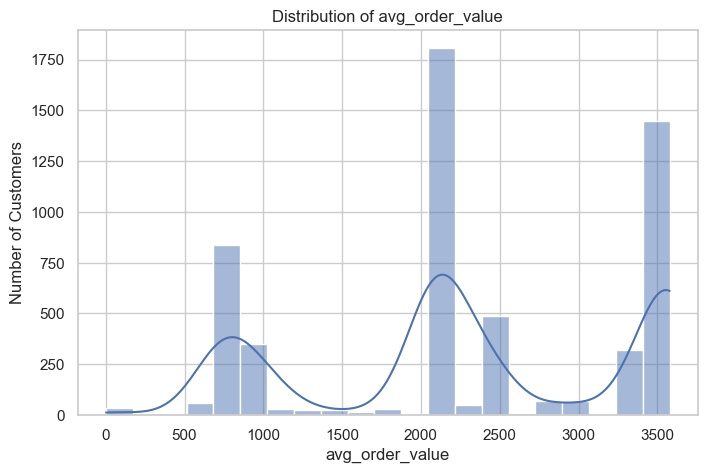

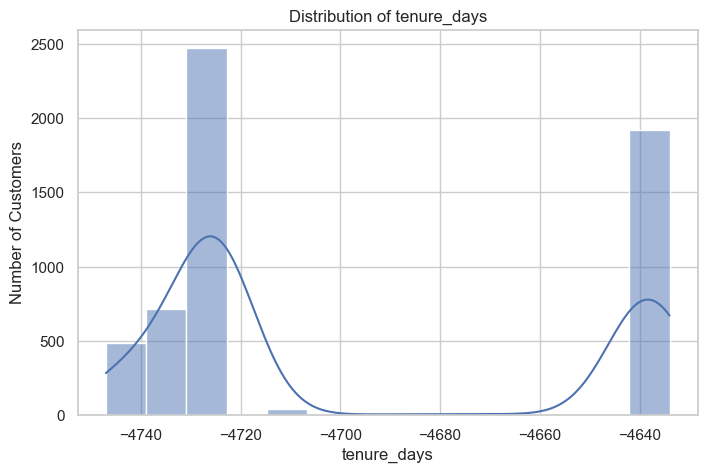

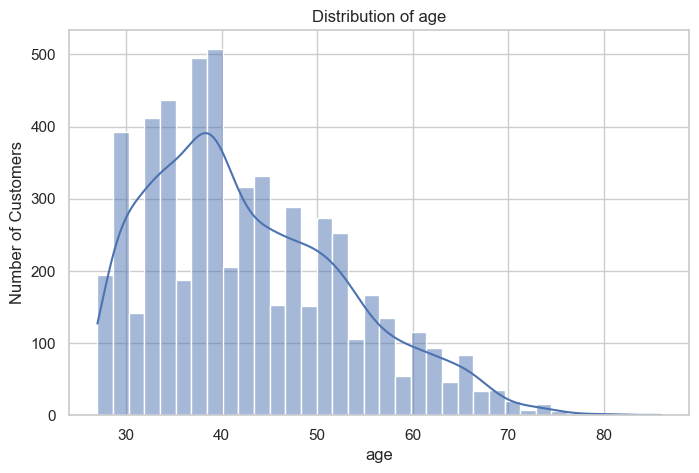

In [22]:
for column in FEATURE_COLS:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    
    plt.show()

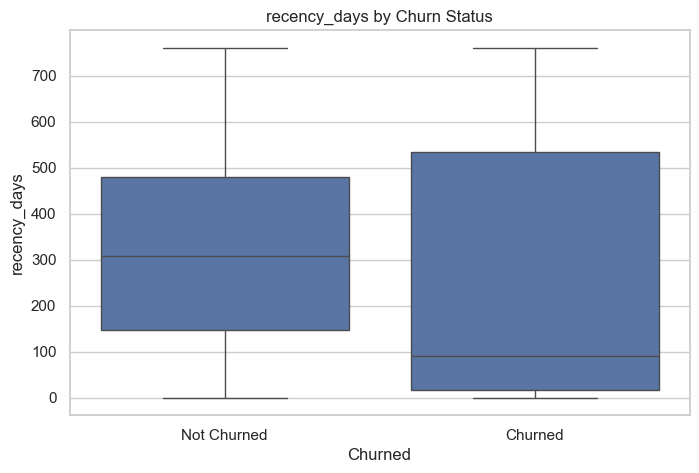

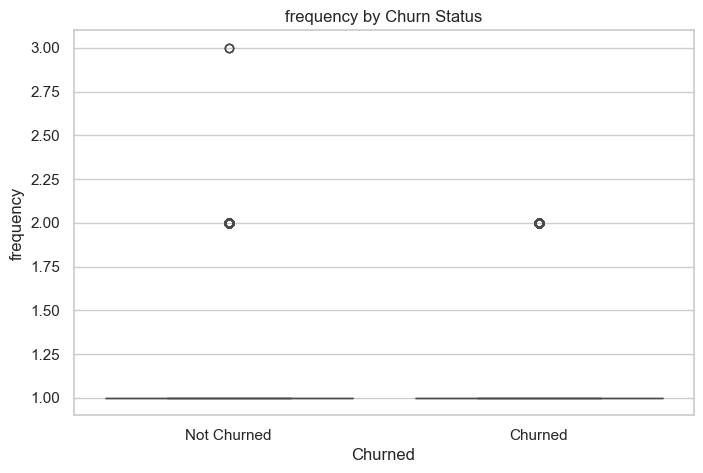

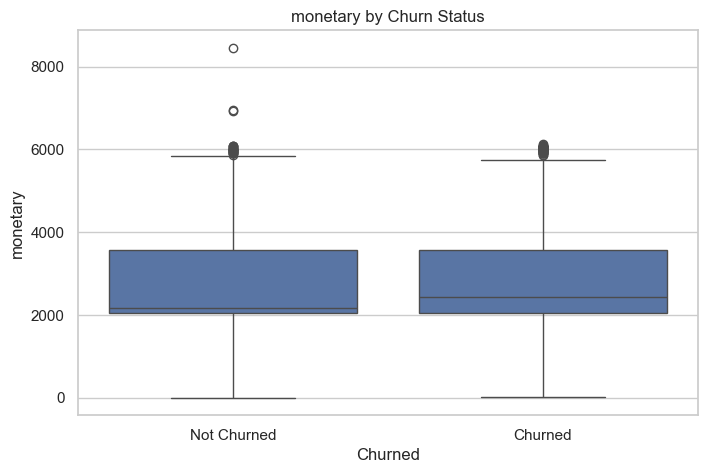

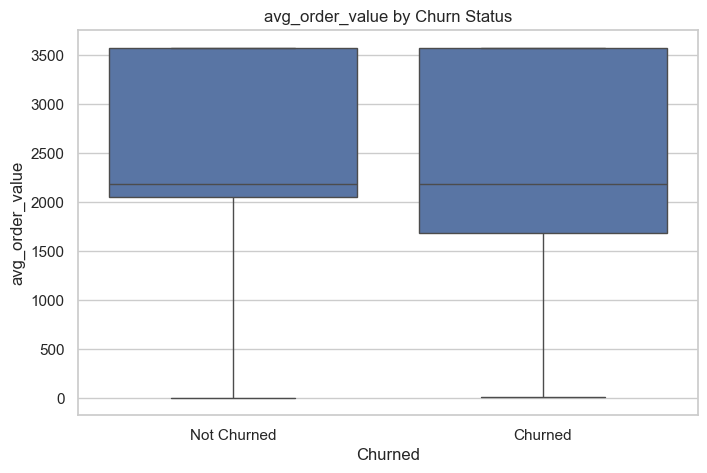

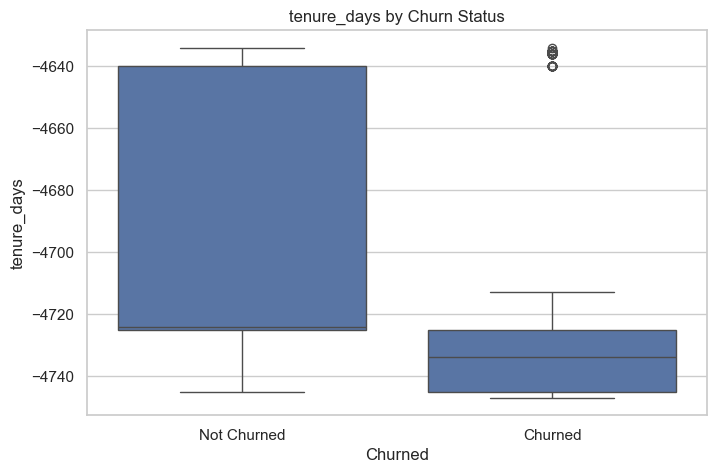

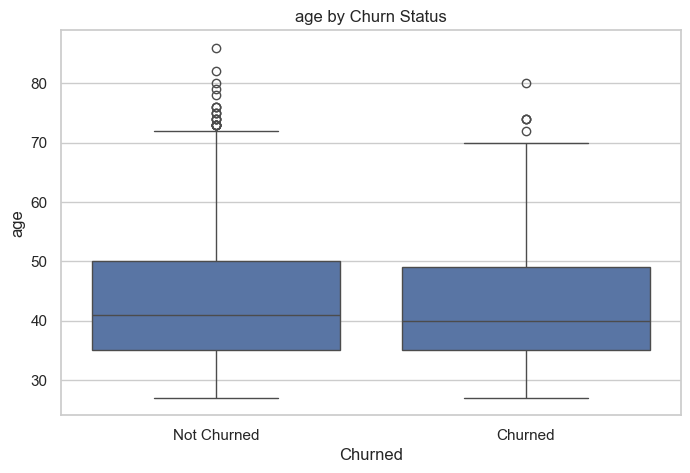

In [23]:
for column in FEATURE_COLS:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="churned",
        y=column
    )
    
    plt.title(f"{column} by Churn Status")
    plt.xlabel("Churned")
    plt.ylabel(column)
    
    plt.xticks(
        [0, 1],
        ["Not Churned", "Churned"]
    )
    
    plt.show()

In [25]:
churn_summary = (
    df.groupby("churned")[FEATURE_COLS]
    .mean()
    .T
)

churn_summary.columns = [
    "Not Churned",
    "Churned"
]

churn_summary

,Not Churned,Churned
recency_days,326.512359,237.918618
frequency,1.029116,1.198439
monetary,2373.909510,2686.270903
avg_order_value,2299.278523,2283.551282
tenure_days,-4692.240888,-4727.602007
age,42.939769,42.484375


In [26]:
churn_comparison = churn_summary.copy()

churn_comparison["Difference"] = (
    churn_comparison["Churned"]
    - churn_comparison["Not Churned"]
)

churn_comparison

,Not Churned,Churned,Difference
recency_days,326.512359,237.918618,-88.593741
frequency,1.029116,1.198439,0.169323
monetary,2373.909510,2686.270903,312.361393
avg_order_value,2299.278523,2283.551282,-15.727241
tenure_days,-4692.240888,-4727.602007,-35.361119
age,42.939769,42.484375,-0.455394


## 5. Categorical Feature Analysis

We now analyze customer characteristics such as:

- Gender
- Marital status
- Country

In [27]:
categorical_features = [
    "gender",
    "marital_status",
    "country"
]

for column in categorical_features:
    print(f"\n===== {column.upper()} =====")
    print(df[column].value_counts(dropna=False))


===== GENDER =====
gender
Male      2810
Female    2676
n/a        185
Name: count, dtype: int64

===== MARITAL_STATUS =====
marital_status
Married    2870
Single     2801
Name: count, dtype: int64

===== COUNTRY =====
country
Australia         1916
United States     1392
United Kingdom     599
Germany            535
France             512
Canada             360
USA                343
n/a                 14
Name: count, dtype: int64


In [28]:
gender_churn = pd.crosstab(
    df["gender"],
    df["churned"],
    normalize="index"
) * 100

gender_churn

churned,False,True
gender,,
Female,84.379671,15.620329
Male,83.807829,16.192171
n/a,87.027027,12.972973


In [29]:
marital_churn = pd.crosstab(
    df["marital_status"],
    df["churned"],
    normalize="index"
) * 100

marital_churn

churned,False,True
marital_status,,
Married,84.320557,15.679443
Single,84.041414,15.958586


In [30]:
country_churn = (
    df.groupby("country")
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("churned", "mean")
    )
    .sort_values("customers", ascending=False)
)

country_churn["churn_rate"] *= 100

country_churn.head(15)

,customers,churn_rate
country,,
Australia,1916,4.018789
United States,1392,28.591954
United Kingdom,599,8.681135
Germany,535,11.028037
France,512,16.601562
Canada,360,45.000000
USA,343,14.577259
n/a,14,100.000000


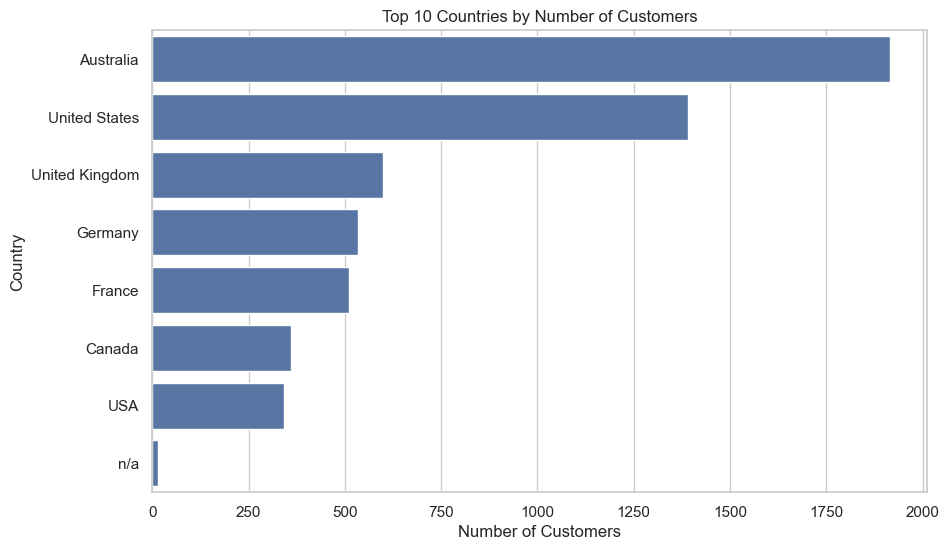

In [31]:
top_countries = (
    df["country"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Country")

plt.show()

## 6. Correlation Analysis

We examine the relationships between numerical variables and the churn
target.

Correlation does not imply causation, but it can help identify useful
features and potential relationships for further analysis.

In [34]:
correlation = df[
    FEATURE_COLS + ["churned"]
].corr()

correlation

,recency_days,frequency,monetary,avg_order_value,tenure_days,age,churned
recency_days,1.000000,-0.327827,0.343747,0.566451,-0.003588,-0.009222,-0.148155
frequency,-0.327827,1.000000,0.437886,-0.007851,0.116825,0.007581,0.266302
monetary,0.343747,0.437886,1.000000,0.884162,0.169706,-0.002753,0.096326
avg_order_value,0.566451,-0.007851,0.884162,1.000000,0.117640,-0.010097,-0.005617
tenure_days,-0.003588,0.116825,0.169706,0.117640,1.000000,0.018488,-0.297841
age,-0.009222,0.007581,-0.002753,-0.010097,0.018488,1.000000,-0.016088
churned,-0.148155,0.266302,0.096326,-0.005617,-0.297841,-0.016088,1.000000


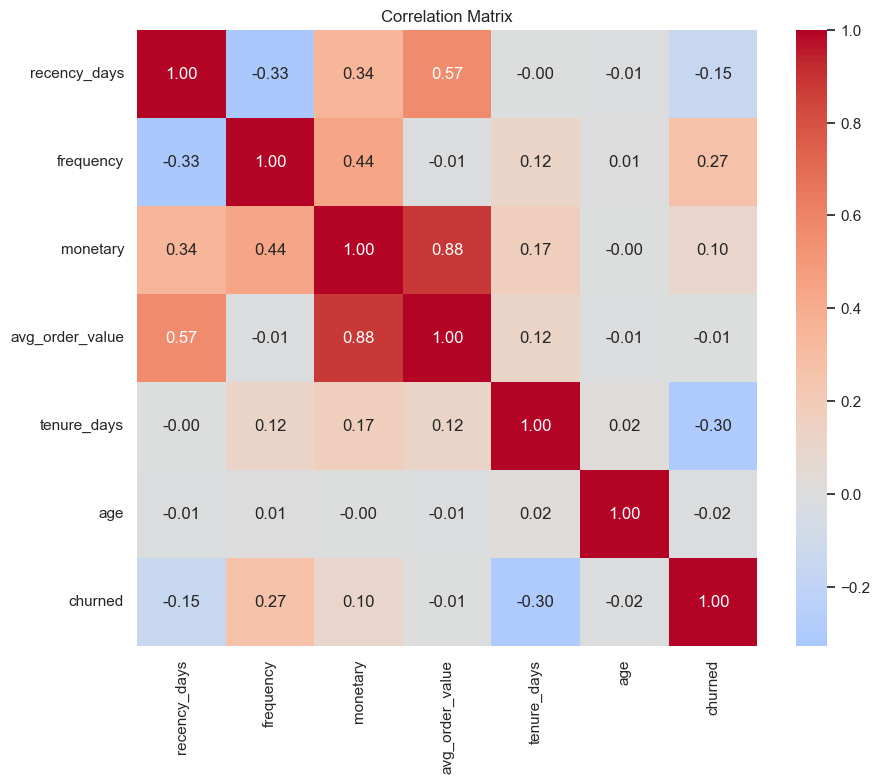

In [35]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [36]:
churn_correlations = (
    correlation["churned"]
    .drop("churned")
    .sort_values(
        key=abs,
        ascending=False
    )
)

churn_correlations

tenure_days       -0.297841
frequency          0.266302
recency_days      -0.148155
monetary           0.096326
age               -0.016088
avg_order_value   -0.005617
Name: churned, dtype: float64

In [37]:
checks = {
    "negative_recency": (df["recency_days"] < 0).sum(),
    "negative_frequency": (df["frequency"] < 0).sum(),
    "negative_monetary": (df["monetary"] < 0).sum(),
    "negative_aov": (df["avg_order_value"] < 0).sum(),
    "negative_tenure": (df["tenure_days"] < 0).sum(),
    "invalid_age": ((df["age"] < 0) | (df["age"] > 120)).sum()
}

pd.Series(checks)

negative_recency         0
negative_frequency       0
negative_monetary        0
negative_aov             0
negative_tenure       5671
invalid_age              0
dtype: int64

In [38]:
print("Unique churn values:")
print(df["churned"].unique())

Unique churn values:
[False  True]


In [39]:
summary = pd.DataFrame({
    "Metric": [
        "Number of customers",
        "Number of features",
        "Churned customers",
        "Non-churned customers",
        "Churn rate",
        "Missing values",
        "Duplicate rows"
    ],
    "Value": [
        len(df),
        len(df.columns) - 1,
        (df["churned"] == 1).sum(),
        (df["churned"] == 0).sum(),
        f"{df['churned'].mean() * 100:.2f}%",
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

summary

,Metric,Value
0,Number of customers,5671
1,Number of features,10
2,Churned customers,897
3,Non-churned customers,4774
4,Churn rate,15.82%
5,Missing values,10
6,Duplicate rows,0


## 7. EDA Conclusions

### Dataset

The dataset contains one record per customer and includes behavioral,
financial, demographic, and geographic features.

### Behavioral Features

The main behavioral variables are:

- Recency
- Frequency
- Monetary value
- Average order value
- Customer tenure

These variables provide information about customer engagement and
purchasing behavior.

### Data Quality

The analysis checked:

- Missing values
- Duplicate customers
- Invalid numerical values
- Target validity
- Customer-level uniqueness

### Churn Distribution

The distribution of the `churned` target should be considered before
model training, particularly if the classes are imbalanced.